<a href="https://colab.research.google.com/github/trangoi1610/housingPricePrediction/blob/main/Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# abccsjdcdcn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data = pd.read_csv('housing.csv')

In [6]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
data.dropna(inplace=True)

In [7]:
from sklearn.model_selection import train_test_split
x = data.drop(['median_house_value'], axis=1)
y = data['median_house_value']

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [9]:
train_data = x_train.join(y_train)

In [10]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
6883,-118.09,34.06,38.0,3230.0,840.0,3485.0,827.0,2.6290,<1H OCEAN,171600.0
965,-121.88,37.68,23.0,2234.0,270.0,854.0,286.0,7.3330,INLAND,337200.0
17142,-122.18,37.45,43.0,2061.0,437.0,817.0,385.0,4.4688,NEAR BAY,460200.0
9217,-120.26,37.11,33.0,1097.0,254.0,627.0,253.0,1.2794,INLAND,50700.0
9551,-120.88,37.37,24.0,1294.0,222.0,684.0,221.0,2.6908,INLAND,103100.0
...,...,...,...,...,...,...,...,...,...,...
3498,-118.45,34.27,33.0,1194.0,229.0,839.0,230.0,3.7050,<1H OCEAN,185800.0
18271,-122.09,37.36,37.0,1550.0,238.0,805.0,250.0,5.0222,NEAR BAY,500001.0
11583,-118.04,33.76,25.0,4061.0,545.0,1623.0,527.0,7.1572,<1H OCEAN,294900.0
6311,-118.00,34.03,25.0,6909.0,1154.0,3912.0,1121.0,5.2570,<1H OCEAN,226100.0


histogram

In [18]:
train_data.hist(15,8)

KeyError: 8

heat map

In [11]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")

ValueError: could not convert string to float: '<1H OCEAN'

<Figure size 1500x800 with 0 Axes>

In [17]:
train_data['total_rooms'] = np.log(train_data['total_room'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedroom'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)

KeyError: 'total_room'

this make the hitogram not to skew (use log)

In [ ]:
train_data.hist(15,8)

move the ocean_proximity from words to number

In [12]:
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity)).drop(['ocean_proximity'], axis=1)

<Axes: >

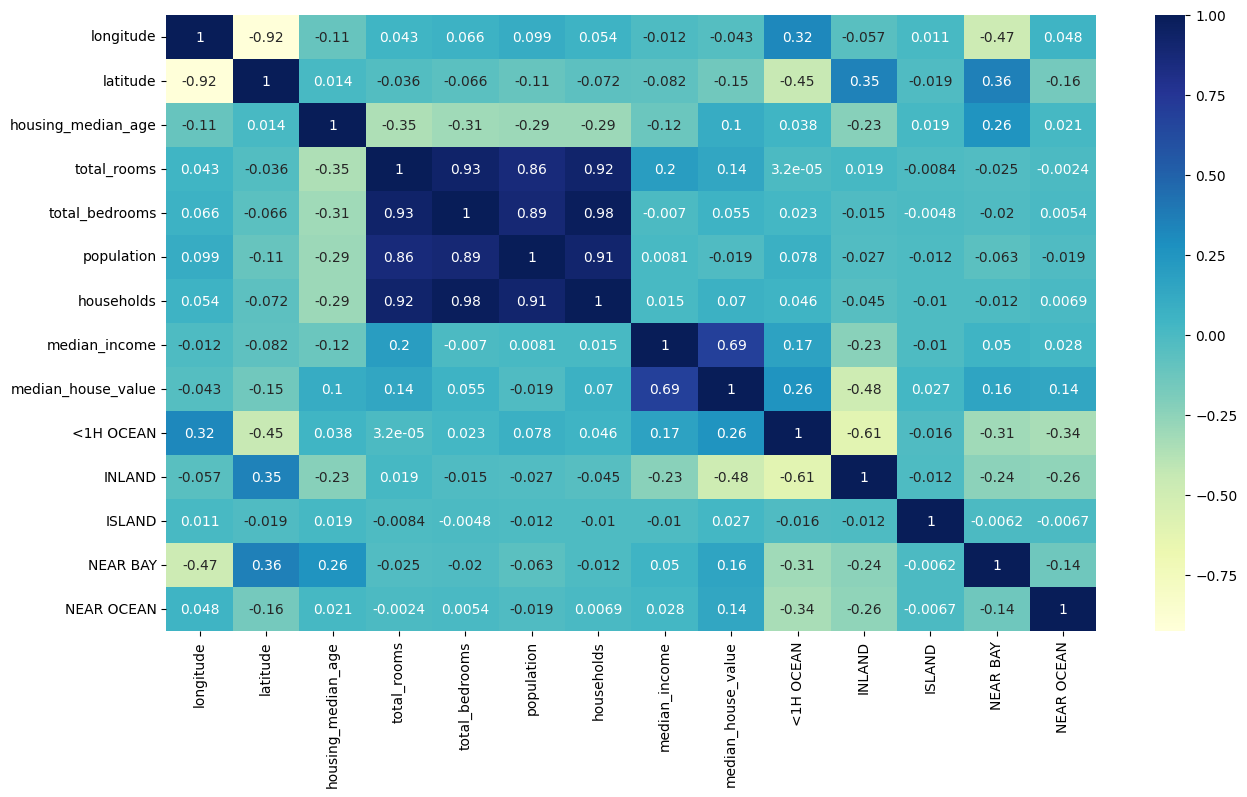

In [16]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")

visualize by the locatioin the map

In [ ]:
plt.figure(figsize=(15,8))
sns.scatterplot(x="latitude", y="longtitude", data=train_data, hue="median_house_value", palette="coolwarm")

In [8]:
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms'] / train_data[households]

NameError: name 'train_data' is not defined

In [ ]:
from sklearn.linear_model import LinearRegression
x = train_data.drop(['median_house_value'], axis=1)
y = train_data['median_house_value']
reg = LinearRegression()
reg.fix(x_train, y_train)


In [ ]:
test_data = x_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_room'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedroom'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)

test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity)).drop(['ocean_proximity'], axis=1)

test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['household_rooms'] = test_data['total_rooms'] / test_data['households']




In [ ]:
reg.cr